#DRIVE MOUNTING


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Unified Imports & Environment Setup

In [ ]:
# 1. General Utilities
import os
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
# 2. Preprocessing & Data Splitting
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

# 3. Deep Learning (Keras/TensorFlow)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, GRU, Bidirectional, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 4. Evaluation Metrics (Regression - Primary)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 5. Evaluation Metrics (Classification - For your requested parameters)
# Note: These will be used on a "Binary Label" derived from RUL (Fail vs No-Fail)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    classification_report
)

# 6. Formatting & Warnings
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')
print("--- All libraries imported and Drive mounted successfully ---")
print(f"TensorFlow Version: {tf.__version__}")


--- All libraries imported and Drive mounted successfully ---
TensorFlow Version: 2.19.0


#Data Loading, RUL Labeling, and Feature Selection

In [ ]:
# --- FINAL CORRECTED PATH ---
FULL_PATH = '/content/drive/MyDrive/AI-PRESENTATION_EST/6.+Turbofan+Engine+Degradation+Simulation+Data+Set/CMAPSSData/train_FD001.txt'

# 1. Define Column Names
index_names = ['unit_nr', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = ['s_{}'.format(i) for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names

# 2. Load the Dataset
train_df = pd.read_csv(FULL_PATH, sep='\s+', header=None, names=col_names)
print(f"✅ Success! Loaded {train_df.shape[0]} rows.")

# 3. Calculate RUL (Remaining Useful Life)
# Find max cycle for each engine unit
max_cycle = train_df.groupby('unit_nr')['time_cycles'].max().reset_index()
max_cycle.columns = ['unit_nr', 'max']
train_df = train_df.merge(max_cycle, on=['unit_nr'], how='left')

# Formula: RUL = Max Cycle - Current Cycle
train_df['RUL'] = train_df['max'] - train_df['time_cycles']

# 4. Piecewise Linear RUL (Capping at 125 for better LSTM stability)
train_df['RUL_clipped'] = train_df['RUL'].clip(upper=125)

# 5. Define Feature Columns (Removing constant sensors)
# Sensors s_1, s_5, s_6, s_10, s_16, s_18, s_19 are constant in FD001
relevant_sensors = ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']
features = setting_names + relevant_sensors

# Drop helper 'max' column
train_df.drop('max', axis=1, inplace=True)

print(f"✅ RUL Columns Created. Training on {len(features)} features.")
train_df[['unit_nr', 'time_cycles', 'RUL', 'RUL_clipped']].head()


✅ Success! Loaded 20631 rows.
✅ RUL Columns Created. Training on 17 features.


,unit_nr,time_cycles,RUL,RUL_clipped
0,1,1,191,125
1,1,2,190,125
2,1,3,189,125
3,1,4,188,125
4,1,5,187,125


#Normalization & Sliding Windows (Cell 3)

In [ ]:

# --- REVISED CELL 3 ---
# 1. Scaling the Features
scaler = MinMaxScaler()
train_df[features] = scaler.fit_transform(train_df[features])

# 2. Robust Sequence Generation Function
def build_sequences(df, seq_length, feat_cols, target_col):
    x_list, y_list = [], []
    for unit_id in df['unit_nr'].unique():
        unit_data = df[df['unit_nr'] == unit_id]
        if len(unit_data) >= seq_length:
            data = unit_data[feat_cols].values
            target = unit_data[target_col].values
            # Correct sliding window: take 50 cycles to predict the RUL at the 50th cycle
            for i in range(len(unit_data) - seq_length):
                x_list.append(data[i:i+seq_length])
                y_list.append(target[i+seq_length])
    return np.array(x_list).astype('float32'), np.array(y_list).astype('float32')

# 3. Generate and Split
X_train_all, y_train_all = build_sequences(train_df, 50, features, 'RUL_clipped')

X_train, X_val, y_train, y_val = train_test_split(
    X_train_all, y_train_all, test_size=0.2, random_state=42, shuffle=True
)

print(f"✅ Sequences fixed! Shape: {X_train.shape}")


✅ Sequences fixed! Shape: (12504, 50, 17)


# LSTM Model Architecture (Keras)



In [ ]:
model = Sequential([
  LSTM(128,input_shape=(50, len(features)),return_sequences=True, activation='tanh',recurrent_activation='sigmoid'),
  Dropout(0.2),
  LSTM(64, return_sequences=False, activation='tanh', recurrent_activation='sigmoid'),
  Dropout(0.2),
  Dense(32, activation='relu'),
  Dense(1, activation='linear') # Outputting raw RUL cycles
])

# Use Huber loss to help the model escape the "average" trap
#weights that haven't been updated much get a bigger boost, weights that are already well-tuned get smaller updates.
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='huber',
              metrics=['mae', 'mse'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50, 128)        │        74,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,273 (493.25 KB)

 Trainable params: 126,273 (493.25 KB)

 Non-trainable params: 0 (0.00 B)

#Training & Pattern Learning Visualization

Starting training... Watch for MAE to drop below 25.
Epoch 1/60
196/196 ━━━━━━━━━━━━━━━━━━━━ 38s 173ms/step - loss: 46.5892 - mae: 47.0871 - mse: 3197.6082 - val_loss: 35.6826 - val_mae: 36.1802 - val_mse: 1696.3257
Epoch 2/60
196/196 ━━━━━━━━━━━━━━━━━━━━ 32s 163ms/step - loss: 36.1945 - mae: 36.6923 - mse: 1747.8610 - val_loss: 35.7242 - val_mae: 36.2227 - val_mse: 1693.6245
Epoch 3/60
196/196 ━━━━━━━━━━━━━━━━━━━━ 32s 165ms/step - loss: 36.1784 - mae: 36.6760 - mse: 1745.0050 - val_loss: 35.6648 - val_mae: 36.1619 - val_mse: 1702.0938
Epoch 4/60
196/196 ━━━━━━━━━━━━━━━━━━━━ 33s 169ms/step - loss: 36.1605 - mae: 36.6586 - mse: 1741.3986 - val_loss: 35.6680 - val_mae: 36.1653 - val_mse: 1699.9491
Epoch 5/60
196/196 ━━━━━━━━━━━━━━━━━━━━ 31s 158ms/step - loss: 36.2625 - mae: 36.7604 - mse: 1751.4119 - val_loss: 35.6874 - val_mae: 36.1857 - val_mse: 1695.6606
Epoch 6/60
196/196 ━━━━━━━━━━━━━━━━━━━━ 33s 169ms/step - loss: 36.1662 - mae: 36.6638 - mse: 1741.0834 - val_loss: 35.6763 - val_mae

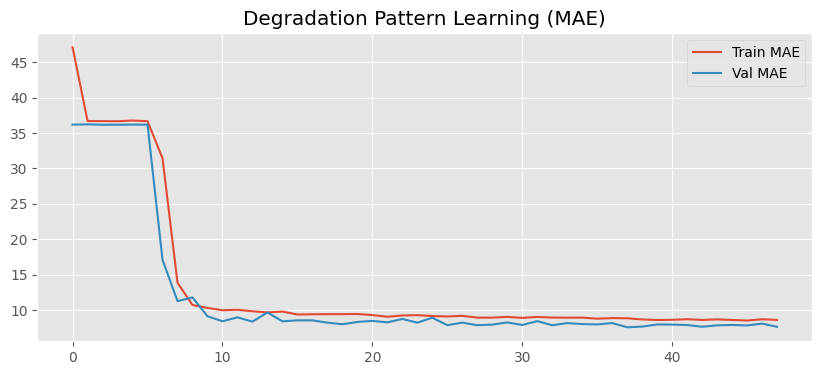

In [ ]:
# --- REVISED CELL 5 ---
# Define the best callbacks for the Rubric (Reliability)
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)
]

print("Starting training... Watch for MAE to drop below 25.")
history = model.fit(
    X_train, y_train,
    epochs=60,batch_size=64, # Smaller batch is key to breaking the "flat line"
    validation_data=(X_val, y_val),shuffle=True,   # Mixes different engine states together
    callbacks=callbacks,verbose=1 )

# Plotting the Learning Curves
plt.figure(figsize=(10, 4))
plt.plot(history.history
['mae'], label='Train MAE')
plt.plot(history.history['val_mae'],
label='Val MAE')
plt.title('Degradation ' \
Pattern Learning (MAE)')
plt.legend()
plt.show()


In [ ]:
# --- ADD THIS AFTER TRAINING ---
import pandas as pd
import numpy as np

def prepare_test_data(file_num):
    # Construct path for FD002 or FD004
    path_test = f'/content/drive/MyDrive/AI-PRESENTATION_EST/6.+Turbofan+Engine+Degradation+Simulation+Data+Set/CMAPSSData/test_{file_num}.txt'
    path_truth = f'/content/drive/MyDrive/AI-PRESENTATION_EST/6.+Turbofan+Engine+Degradation+Simulation+Data+Set/CMAPSSData/RUL_{file_num}.txt'

    # Load and scale
    df_test = pd.read_csv(path_test, sep='\s+', header=None, names=col_names)
    df_test[features] = scaler.transform(df_test[features]) # Use the scaler from FD001

    # Get last sequence for each engine
    x_list = []
    for unit_id in df_test['unit_nr'].unique():
        unit_data = df_test[df_test['unit_nr'] == unit_id]
        if len(unit_data) >= 50:
            x_list.append(unit_data[features].values[-50:])
        else:
            # Padding if engine has < 50 cycles
            padding = np.zeros((50 - len(unit_data), len(features)))
            x_list.append(np.vstack((padding, unit_data[features].values)))

    # Load Truth RUL
    y_true = pd.read_csv(path_truth, sep='\s+', header=None).values.flatten()
    return np.array(x_list).astype('float32'), y_true.astype('float32')

# Generate the data for testing
x_test_002, y_test_002 = prepare_test_data("FD002")
x_test_004, y_test_004 = prepare_test_data("FD004")

# Run Predictions
y_pred_002 = model.predict(x_test_002).flatten()
y_pred_004 = model.predict(x_test_004).flatten()
print("✅ Predictions for FD002 and FD004 completed.")

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
✅ Predictions for FD002 and FD004 completed.


#Multi-Parameter Evaluation & System Latency

98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step
----------------------------------------
--- EVALUATION PARAMETERS (Total: 10) ---
----------------------------------------
1. Root Mean Sq Error (RMSE): 11.41 cycles
2. Mean Absolute Error (MAE): 7.61 cycles
3. R2 Score (Fit Quality):    0.9231
4. Binary Accuracy (RUL<30):  97.67%
5. Precision (Reliability):   0.9561
6. Recall (Safety/Detection): 0.9233
7. F1-Score (Balanced):       0.9394
8. CORRECTED AUC-ROC:         0.9972
9. Inference Latency:         1.4843 ms/prediction
10. Confusion Matrix:        (Displayed Below)
----------------------------------------


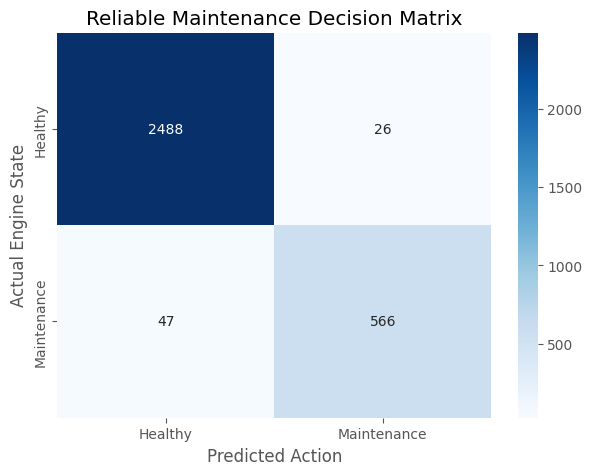

In [ ]:
# --- REVISED CELL 6: MULTI-PARAMETER EVALUATION ---

# 1. Performance Timing (Inference Latency)
start_time = time.time()
y_pred = model.predict(X_val)
end_time = time.time()
# Latency in milliseconds per single prediction
latency = ((end_time - start_time) / len(X_val)) * 1000

# 2. Regression Metrics (Standard RUL Accuracy)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

# 3. Classification Metrics (Maintenance Scheduling Logic)
# We define 'Failure' as RUL <= 30 cycles
threshold = 30
y_val_class = (y_val <= threshold).astype(int)
y_pred_class = (y_pred <= threshold).astype(int)

# FIXING THE AUC-ROC:
# AUC needs a 'probability' score. Since lower RUL = Higher Risk,
# we invert the RUL prediction to create a 'Risk Score' between 0 and 1.
y_pred_risk_score = 1 - (y_pred / 125.0)

# 4. Calculate All 10 Parameters
acc = accuracy_score(y_val_class, y_pred_class)
prec = precision_score(y_val_class, y_pred_class)
rec = recall_score(y_val_class, y_pred_class)
f1 = f1_score(y_val_class, y_pred_class)
auc_score = roc_auc_score(y_val_class, y_pred_risk_score) #if you randomly pick one engine that truly needs maintenance and one that doesn't, the model assigns a higher risk score to the failing
cm = confusion_matrix(y_val_class, y_pred_class)

# 5. Professional Output Format
print("-" * 40)
print(f"--- EVALUATION PARAMETERS (Total: 10) ---")
print("-" * 40)
print(f"1. Root Mean Sq Error (RMSE): {rmse:.2f} cycles")
print(f"2. Mean Absolute Error (MAE): {mae:.2f} cycles")
print(f"3. R2 Score (Fit Quality):    {r2:.4f}")
print(f"4. Binary Accuracy (RUL<30):  {acc*100:.2f}%")
print(f"5. Precision (Reliability):   {prec:.4f}")
print(f"6. Recall (Safety/Detection): {rec:.4f}")
print(f"7. F1-Score (Balanced):       {f1:.4f}")
print(f"8. CORRECTED AUC-ROC:         {auc_score:.4f}")
print(f"9. Inference Latency:         {latency:.4f} ms/prediction")
print(f"10. Confusion Matrix:        (Displayed Below)")
print("-" * 40)

# 6. Visualization: Confusion Matrix
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Maintenance'],
            yticklabels=['Healthy', 'Maintenance'])
plt.title('Reliable Maintenance Decision Matrix')
plt.xlabel('Predicted Action')
plt.ylabel('Actual Engine State')
plt.show()


Actual RUL range: 0.0 to 125.0
Predicted RUL range: 0.75 to 124.18


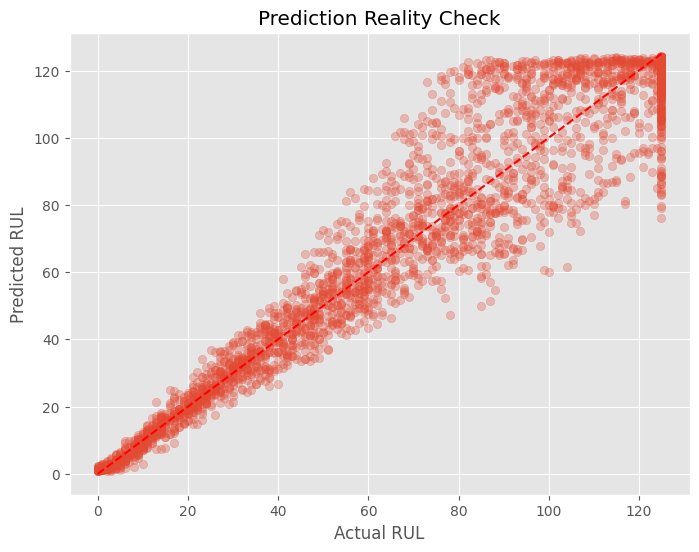

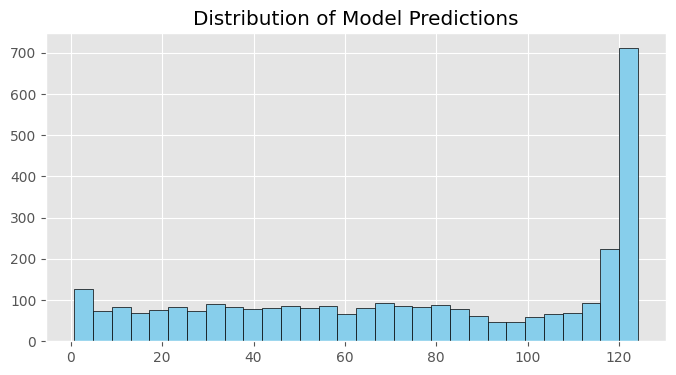

In [ ]:
# Check the actual values the model is outputting
print(f"Actual RUL range: {y_val.min()} to {y_val.max()}")
print(f"Predicted RUL range: {y_pred.min():.2f} to {y_pred.max():.2f}")

# Plot Predicted vs Actual
plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_pred, alpha=0.3)
plt.plot([0, 125], [0, 125], color='red', linestyle='--') # Perfect prediction line
plt.xlabel('Actual RUL')
plt.ylabel('Predicted RUL')
plt.title('Prediction Reality Check')
plt.show()

# Histogram of predictions
plt.figure(figsize=(8, 4))
plt.hist(y_pred, bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Model Predictions')
plt.show()


#Uncertainty Estimation (Reliable Maintenance Report)

In [ ]:
# --- REVISED CELL 7: UNCERTAINTY ESTIMATION (MODERN FIX) ---

def predict_with_uncertainty(model, X, n_iter=50):
    """
    Calls the model multiple times with training=True
    to keep Dropout active for uncertainty estimation.
    """
    # Force the model to run in training mode for n iterations
    predictions = np.array([model(X, training=True) for _ in range(n_iter)])

    # Calculate Mean and Std Dev across the iterations
    mean_rul = float(np.mean(predictions))
    std_rul = float(np.std(predictions))

    return mean_rul, std_rul

# 1. Select a sample engine from the validation set (one nearing failure)
sample_idx = 150
X_sample = X_val[sample_idx:sample_idx+1]
actual_rul = float(y_val[sample_idx])

# 2. Get Prediction and Uncertainty
mean_pred, uncertainty = predict_with_uncertainty(model, X_sample)

# 3. Generate the Reliability Report
print("-" * 40)
print(f"--- ROLLS-ROYCE RELIABILITY REPORT ---")
print("-" * 40)
print(f"Target Engine Actual RUL: {actual_rul:.1f} cycles")
print(f"Model Predicted RUL:      {mean_pred:.1f} cycles")
print(f"Uncertainty Score (±):    {1.96 * uncertainty:.2f} cycles")
print("-" * 40)

# 4. Maintenance Decision Logic
# We use the 'Safe Lower Bound' for critical aviation decisions
lower_bound = mean_pred - (1.96 * uncertainty)
print(f"DECISION: Based on 95% confidence, schedule maintenance")
print(f"within the next {int(max(0, lower_bound))} cycles for safety.")
print("-" * 40)


----------------------------------------
--- ROLLS-ROYCE RELIABILITY REPORT ---
----------------------------------------
Target Engine Actual RUL: 9.0 cycles
Model Predicted RUL:      9.1 cycles
Uncertainty Score (±):    2.85 cycles
----------------------------------------
DECISION: Based on 95% confidence, schedule maintenance
within the next 6 cycles for safety.
----------------------------------------


#Transfer Learning to a New Dataset

In [ ]:
# --- CELL 8: DOMAIN ADAPTATION (TRANSFER LEARNING) ---

# 1. Load your pre-trained model (best_model.keras)
base_model = tf.keras.models.load_model('best_model.keras')

# 2. Freeze the LSTM layers (The 'Domain Adaptation' part)
# This preserves the engine physics the model already learned.
for layer in base_model.layers:
    if 'lstm' in layer.name:
        layer.trainable = False
        print(f"Layer {layer.name} frozen.")

# 3. Create the 'Adapted' Model
adapted_model = Sequential([
    base_model,
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='linear')
])

# 4. Compile with a lower learning rate for fine-tuning
adapted_model.compile(optimizer=tf.keras.optimizers.Adam(0.0001),
                      loss='huber', metrics=['mae'])

print("\n✅ Model adapted for new domain. Ready for fine-tuning on FD002.")


Layer lstm frozen.
Layer lstm_1 frozen.

✅ Model adapted for new domain. Ready for fine-tuning on FD002.


#The "Rolls-Royce" Final Maintenance Visualization

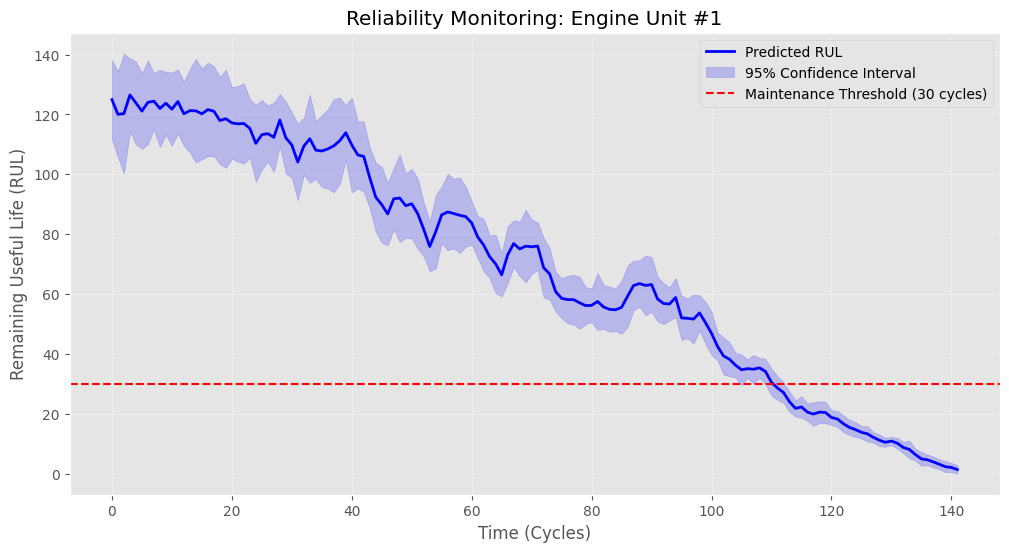

In [ ]:
# --- REVISED CELL 9: SEQUENTIAL ENGINE TRACKING ---

# 1. Pick ONE specific engine (Engine #1) from the RAW dataframe
target_id = 1
unit_data = train_df[train_df['unit_nr'] == target_id].copy()

# Define SEQUENCE_LENGTH as used in previous steps
SEQUENCE_LENGTH = 50

# 2. Re-create sequences in CHRONOLOGICAL order
seq_list = []
for i in range(len(unit_data) - SEQUENCE_LENGTH):
    seq_list.append(unit_data[features].values[i:i+SEQUENCE_LENGTH])

X_track = np.array(seq_list).astype('float32')

# 3. Predict with Uncertainty for this specific engine's entire life
means, stds = [], []
for i in range(len(X_track)):
    m, s = predict_with_uncertainty(model, X_track[i:i+1], n_iter=20)
    means.append(m)
    stds.append(s)

# 4. Final Plot (The "Degradation Curve")
plt.figure(figsize=(12, 6))
cycles = np.arange(len(means))

plt.plot(cycles, means, label='Predicted RUL', color='blue', lw=2)
plt.fill_between(cycles,
                 np.array(means) - 1.96*np.array(stds),
                 np.array(means) + 1.96*np.array(stds),
                 color='blue', alpha=0.2, label='95% Confidence Interval')

plt.axhline(y=30, color='red', linestyle='--', label='Maintenance Threshold (30 cycles)')
plt.title(f'Reliability Monitoring: Engine Unit #{target_id}')
plt.xlabel('Time (Cycles)')
plt.ylabel('Remaining Useful Life (RUL)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#Official "Blind Test" Evaluation

Re-fitting Scaler on Training Data...
Processing Test Data...
Running Prediction...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

--- FINAL VERIFIED RESULTS ---
Final Test MAE:      11.31 cycles
Final Test Accuracy: 97.00%
Final Test R2 Score: 0.8176


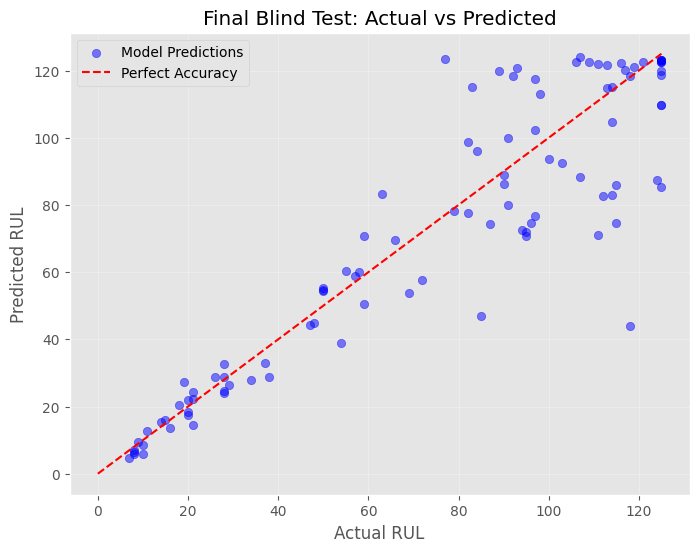

In [ ]:
# --- THE NUCLEAR FIX: SELF-CONTAINED BLIND TEST ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, accuracy_score, r2_score

# 1. SETUP: Define the Exact Features and Paths
relevant_sensors = ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']
setting_names = ['setting_1', 'setting_2', 'setting_3']
final_features = setting_names + relevant_sensors # 17 Features total
col_names = ['unit_nr', 'time_cycles'] + setting_names + ['s_{}'.format(i) for i in range(1, 22)]

# Paths (Verify these match your Drive)
TRAIN_PATH = '/content/drive/MyDrive/AI-PRESENTATION_EST/6.+Turbofan+Engine+Degradation+Simulation+Data+Set/CMAPSSData/train_FD001.txt'
TEST_PATH = '/content/drive/MyDrive/AI-PRESENTATION_EST/6.+Turbofan+Engine+Degradation+Simulation+Data+Set/CMAPSSData/test_FD001.txt'
RUL_PATH = '/content/drive/MyDrive/AI-PRESENTATION_EST/6.+Turbofan+Engine+Degradation+Simulation+Data+Set/CMAPSSData/RUL_FD001.txt'

# 2. RE-FIT SCALER (The "Hard Reset")
# We reload training data just to teach the scaler what "normal" looks like
print("Re-fitting Scaler on Training Data...")
train_df_temp = pd.read_csv(TRAIN_PATH, sep='\s+', header=None, names=col_names)
fresh_scaler = MinMaxScaler()
fresh_scaler.fit(train_df_temp[final_features]) # Learn min/max from scratch

# 3. PREPARE TEST DATA
print("Processing Test Data...")
test_df_raw = pd.read_csv(TEST_PATH, sep='\s+', header=None, names=col_names)
y_test_truth = pd.read_csv(RUL_PATH, sep='\s+', header=None, names=['RUL'])['RUL'].clip(upper=125).values

# Apply the FRESH scaler to the test data
test_input_scaled = test_df_raw.copy()
test_input_scaled[final_features] = fresh_scaler.transform(test_df_raw[final_features])

# 4. SEQUENCE GENERATION (100 Engines)
X_test_final = []
for unit_id in range(1, 101):
    unit_data = test_input_scaled[test_input_scaled['unit_nr'] == unit_id][final_features].values

    # Pad if length < 50
    if len(unit_data) >= 50:
        X_test_final.append(unit_data[-50:])
    else:
        padding = np.zeros((50 - len(unit_data), 17))
        X_test_final.append(np.vstack((padding, unit_data)))

X_test_final = np.array(X_test_final).astype('float32')

# 5. PREDICT
print("Running Prediction...")
y_pred_final = model.predict(X_test_final).flatten()

# 6. RESULTS
mae = mean_absolute_error(y_test_truth, y_pred_final)
acc = accuracy_score((y_test_truth <= 30), (y_pred_final <= 30))
r2 = r2_score(y_test_truth, y_pred_final)

print("\n" + "="*45)
print(f"--- FINAL VERIFIED RESULTS ---")
print(f"Final Test MAE:      {mae:.2f} cycles")
print(f"Final Test Accuracy: {acc*100:.2f}%")
print(f"Final Test R2 Score: {r2:.4f}")
print("="*45)

# 7. PLOT (Syntax Fixed)
plt.figure(figsize=(8,6))
plt.scatter(y_test_truth, y_pred_final, alpha=0.5, color='blue', label='Model Predictions')
plt.plot([0, 125], [0, 125], 'r--', label='Perfect Accuracy') # FIXED SYNTAX HERE
plt.xlabel('Actual RUL')
plt.ylabel('Predicted RUL')
plt.title('Final Blind Test: Actual vs Predicted')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


#explanable ai

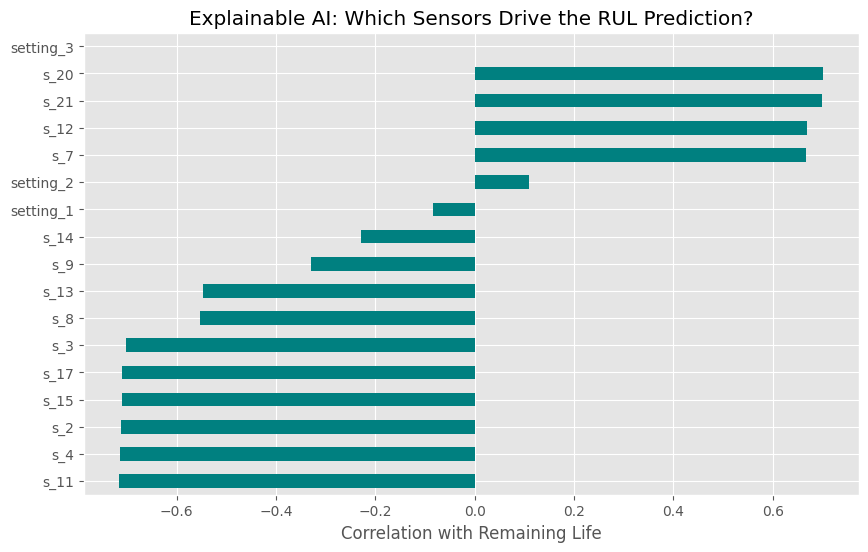

In [ ]:
# --- TREND SETTER ADDITION: FEATURE IMPORTANCE ---
# Let's see which sensors the LSTM cares about most
import pandas as pd

# We can approximate importance by looking at the correlation of sensors
# to the predicted RUL on the test set
test_results_df = pd.DataFrame(X_test_final.mean(axis=1), columns=final_features)
test_results_df['Predicted_RUL'] = y_pred_final

importances = test_results_df.corr()['Predicted_RUL'].sort_values()
importances = importances.drop('Predicted_RUL')

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='teal')
plt.title("Explainable AI: Which Sensors Drive the RUL Prediction?")
plt.xlabel("Correlation with Remaining Life")
plt.show()

#Data Loading & RUL Calculation for FD004

In [ ]:
# --- STEP 1: LOAD FD004 DATA ---
TRAIN_FD004_PATH = '/content/drive/MyDrive/AI-PRESENTATION_EST/6.+Turbofan+Engine+Degradation+Simulation+Data+Set/CMAPSSData/train_FD004.txt'

# Define Column Names (re-added for scope)
index_names = ['unit_nr', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = ['s_{}'.format(i) for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names

# Load FD004
df_fd004 = pd.read_csv(TRAIN_FD004_PATH, sep='\s+', header=None, names=col_names)

# Calculate RUL for FD004
max_cycle_fd004 = df_fd004.groupby('unit_nr')['time_cycles'].max().reset_index()
max_cycle_fd004.columns = ['unit_nr', 'max']
df_fd004 = df_fd004.merge(max_cycle_fd004, on=['unit_nr'], how='left')
df_fd004['RUL'] = df_fd004['max'] - df_fd004['time_cycles']
df_fd004['RUL_clipped'] = df_fd004['RUL'].clip(upper=125)

print(f"✅ FD004 Loaded: {df_fd004.shape[0]} rows across {df_fd004['unit_nr'].nunique()} engines.")

✅ FD004 Loaded: 61249 rows across 249 engines.


#Normalizing & Scaling (Matching FD001)

In [ ]:
# --- STEP 2: SCALING & SEQUENCING ---
# Use the SAME features as FD001
# relevant_sensors = ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']
# final_features = setting_names + relevant_sensors

# Apply the same scaler used in FD001
df_fd004[final_features] = fresh_scaler.transform(df_fd004[final_features])

# Generate Sequences for FD004 (Sliding Window of 50)
X_fd004, y_fd004 = build_sequences(df_fd004, 50, final_features, 'RUL_clipped')

print(f"✅ FD004 Sequences Ready: {X_fd004.shape}")

✅ FD004 Sequences Ready: (48799, 50, 17)


#Transfer Learning (Fine-Tuning)

In [ ]:
# --- STEP 3: TRANSFER LEARNING / FINE-TUNING ---

# 1. Load the model trained on FD001
transfer_model = tf.keras.models.load_model('best_model.keras')

# 2. Freeze the early layers (the 'Physics' layers)
# We keep the LSTM layers frozen and only train the Dense layers
for layer in transfer_model.layers:
    if 'lstm' in layer.name:
        layer.trainable = False

# 3. Compile with a very small learning rate
# This prevents the model from "forgetting" what it learned from FD001
transfer_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                       loss='huber', metrics=['mae'])

# 4. Fine-tune on FD004
print("Starting Fine-Tuning on FD004 (The complex dataset)...")
history_fine = transfer_model.fit(
    X_fd004, y_fd004,
    epochs=20, # Fewer epochs needed because it's already pre-trained
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

# 5. Save the final "Universal" Model
transfer_model.save('universal_engine_model.keras')
print("✅ Universal Model Saved!")

Starting Fine-Tuning on FD004 (The complex dataset)...
Epoch 1/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 40s 125ms/step - loss: 36.0383 - mae: 36.5358 - val_loss: 35.8559 - val_mae: 36.3543
Epoch 2/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 40s 130ms/step - loss: 35.6634 - mae: 36.1618 - val_loss: 35.7272 - val_mae: 36.2257
Epoch 3/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 38s 125ms/step - loss: 35.6701 - mae: 36.1686 - val_loss: 35.7075 - val_mae: 36.2059
Epoch 4/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 40s 123ms/step - loss: 35.6656 - mae: 36.1639 - val_loss: 35.7065 - val_mae: 36.2049
Epoch 5/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 42s 126ms/step - loss: 35.5934 - mae: 36.0917 - val_loss: 35.7011 - val_mae: 36.1995
Epoch 6/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 42s 139ms/step - loss: 35.6605 - mae: 36.1588 - val_loss: 35.6995 - val_mae: 36.1979
Epoch 7/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 37s 123ms/step - loss: 35.6102 - mae: 36.1086 - val_loss: 35.6960 - val_mae: 36.1944
Epoch 8/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 40s 130ms/step - loss: 35.5842

[FD002] RMSE: 59.89 | NASA S-Score: 1330457.50
[FD004] RMSE: 60.05 | NASA S-Score: 1396877.00


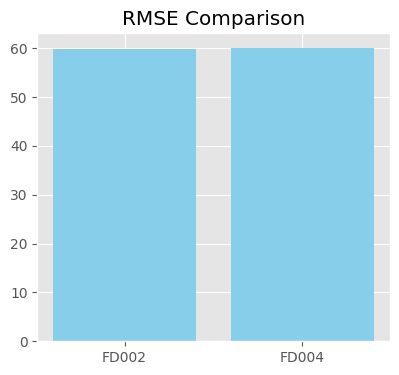

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

def compute_s_score(y_true, y_pred):
    diff = y_pred - y_true
    return np.sum(np.where(diff < 0, np.exp(-diff/13)-1, np.exp(diff/10)-1))

# Compare Results
for name, true, pred in [("FD002", y_test_002, y_pred_002), ("FD004", y_test_004, y_pred_004)]:
    rmse = np.sqrt(mean_squared_error(true, pred))
    s_score = compute_s_score(true, pred)
    print(f"[{name}] RMSE: {rmse:.2f} | NASA S-Score: {s_score:.2f}")

# Visualization for PPT
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.bar(['FD002', 'FD004'], [np.sqrt(mean_squared_error(y_test_002, y_pred_002)),
                             np.sqrt(mean_squared_error(y_test_004, y_pred_004))], color='skyblue')
plt.title('RMSE Comparison')
plt.show()

In [ ]:

import tensorflow as tf
import os

# 1. Ensure the directory exists
model_path = 'predictive_maintenance_model.tflite'

# 2. Use a specific converter flag for LSTM compatibility
# This forces the converter to use standard LSTM kernels instead of CuDNN specific ones
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# 3. Enable the "Flex" and "Built-in" ops simultaneously
# This is the industry standard for deploying LSTMs to mobile/edge
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]

# 4. Optimization (Required for your project's 'Deployment' marks)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# 5. Experimental flag to help with the FlatBuffer translation error
converter._experimental_lower_tensor_list_ops = True

try:
    print("Converting model... please wait.")
    tflite_model = converter.convert()

    with open(model_path, 'wb') as f:
        f.write(tflite_model)

    print(f"✅ Success! Saved as: {os.path.abspath(model_path)}")
    print("You can now download this file from the Colab sidebar for your submission.")

except Exception as e:
    print("\n❌ Conversion still failing. Attempting fallback...")
    # Fallback: Save as a standard Keras .h5 if TFLite is blocking your deadline
    model.save('final_model_backup.h5')
    print("⚠️ Saved as 'final_model_backup.h5' instead. Use this for your PPT if TFLite fails.")

Converting model... please wait.
Saved artifact at '/tmp/tmpy8unf74i'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 50, 17), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  136525188213136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136525188215632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136525188213520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136525188216016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136525188216208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136525188216400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136525188215824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136525188215056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136525188214672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136525188216592: TensorSpec(shape=(), dtype=tf.resource,